# Fintech Review Analytics — Sentiment and Thematic Analysis

## Project Overview

This notebook presents the sentiment and thematic analysis of customer reviews collected from Ethiopian banking applications on the Google Play Store.

The objective is to uncover:

- customer satisfaction patterns
- recurring pain points
- usability issues
- feature requests
- overall sentiment trends

The analysis focuses on:

- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)
- Dashen Bank

---

# Objectives

The notebook performs:

1. Exploratory Data Analysis (EDA)
2. Sentiment Analysis
3. Sentiment Aggregation by Bank
4. Rating Analysis
5. Thematic Analysis
6. Visualization of Business Insights

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

sns.set_style("whitegrid")

# Load Processed Dataset

The processed dataset contains:

- customer reviews
- ratings
- bank information
- sentiment labels
- sentiment scores

In [3]:
df = pd.read_csv(
    "../data/analyzed/processed_reviews.csv"
)

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,processed_review
0,wow,4,2026-05-14,CBE,Google Play,POSITIVE,0.999592,wow
1,nice app,5,2026-05-14,CBE,Google Play,POSITIVE,0.999806,nice app
2,formative,5,2026-05-14,CBE,Google Play,POSITIVE,0.998885,formative
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,POSITIVE,0.996808,good app financial activity
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,NEGATIVE,0.890468,yoroo namaste


# Dataset Overview

We first examine:

- dataset dimensions
- column names
- missing values
- data types

In [4]:
print("Dataset Shape:")

print(df.shape)

print("\nColumns:")

print(df.columns)

print("\nMissing Values:")

print(df.isnull().sum())

Dataset Shape:
(1200, 8)

Columns:
Index(['review', 'rating', 'date', 'bank', 'source', 'sentiment_label',
       'sentiment_score', 'processed_review'],
      dtype='str')

Missing Values:
review               0
rating               0
date                 0
bank                 0
source               0
sentiment_label      0
sentiment_score      0
processed_review    27
dtype: int64


# Sentiment Distribution

This section analyzes the distribution of positive and negative reviews across all banks.

In [5]:
df["sentiment_label"].value_counts()

sentiment_label
POSITIVE    756
NEGATIVE    438
NEUTRAL       6
Name: count, dtype: int64

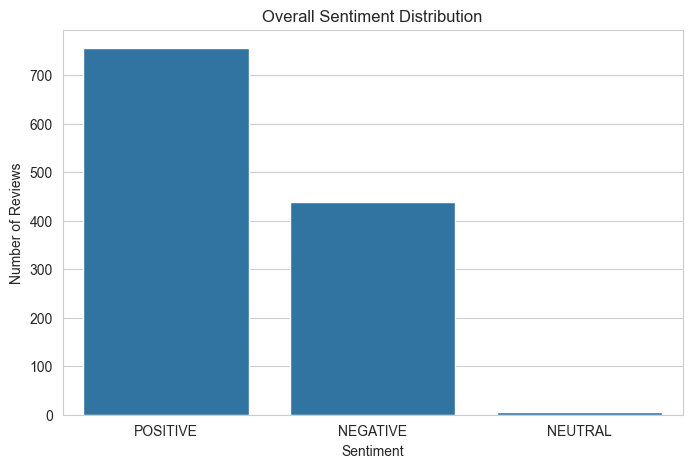

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment_label"
)

plt.title("Overall Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

# Sentiment Distribution by Bank

This visualization compares customer sentiment across the three banking applications.

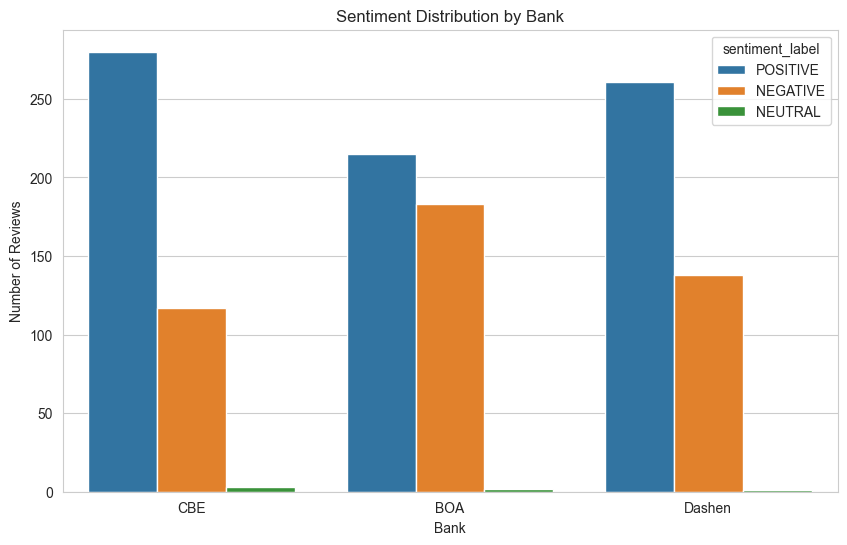

In [7]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bank",
    hue="sentiment_label"
)

plt.title("Sentiment Distribution by Bank")

plt.xlabel("Bank")

plt.ylabel("Number of Reviews")

plt.show()

# Ratings Distribution

Customer ratings provide another indicator of customer satisfaction.

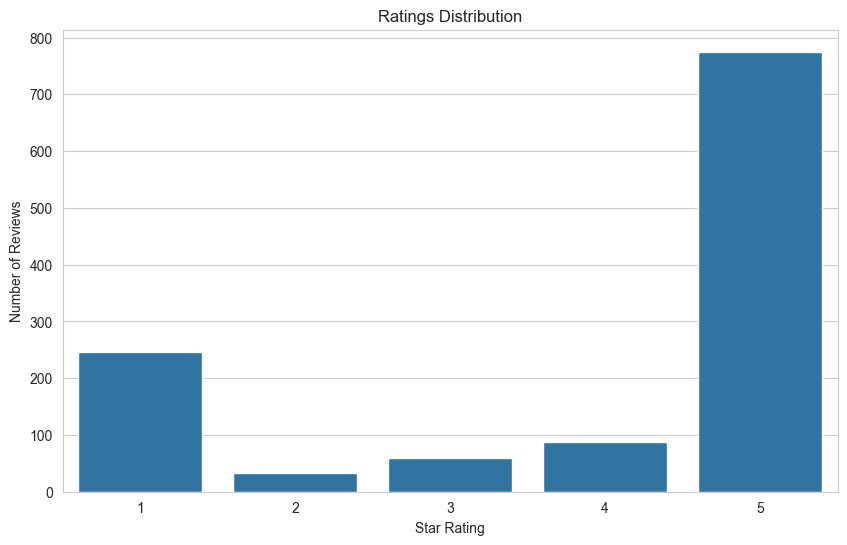

In [8]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="rating"
)

plt.title("Ratings Distribution")

plt.xlabel("Star Rating")

plt.ylabel("Number of Reviews")

plt.show()

# Average Sentiment Score by Bank

This section computes the average sentiment confidence score for each bank.

In [9]:
avg_sentiment = df.groupby(
    "bank"
)["sentiment_score"].mean()

avg_sentiment

bank
BOA       0.962749
CBE       0.980607
Dashen    0.977022
Name: sentiment_score, dtype: float64

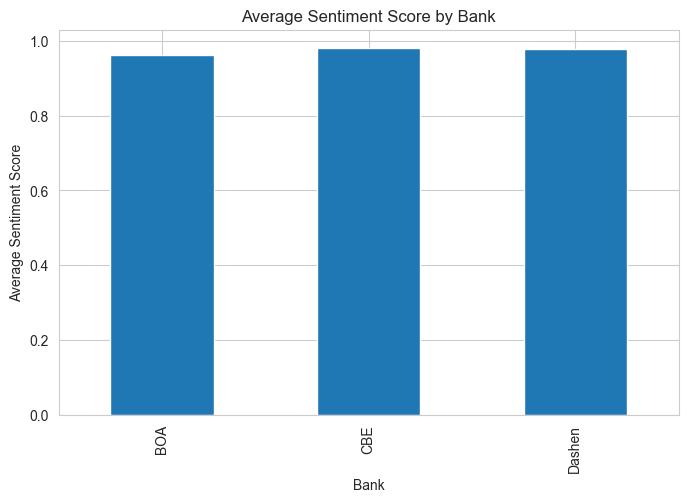

In [10]:
avg_sentiment.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Sentiment Score by Bank")

plt.xlabel("Bank")

plt.ylabel("Average Sentiment Score")

plt.show()

# Load Thematic Analysis Dataset

The thematic dataset contains identified customer concern categories extracted using keyword analysis and TF-IDF.

In [11]:
themes_df = pd.read_csv(
    "../data/analyzed/final_thematic_analysis.csv"
)

themes_df.head()

,review_id,review_text,sentiment_label,sentiment_score,identified_theme
0,1,wow,POSITIVE,0.999592,Other
1,2,nice app,POSITIVE,0.999806,Other
2,3,formative,POSITIVE,0.998885,Other
3,4,best app for financial activities 🙌,POSITIVE,0.996808,Other
4,5,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,NEGATIVE,0.890468,Other


# Theme Frequency Analysis

This section analyzes the most common business themes identified in customer reviews.

In [12]:
themes_df["identified_theme"].value_counts()

identified_theme
Other                      958
Transaction Performance     79
UI & Design                 61
Customer Support            38
Feature Requests            34
Account Access Issues       30
Name: count, dtype: int64

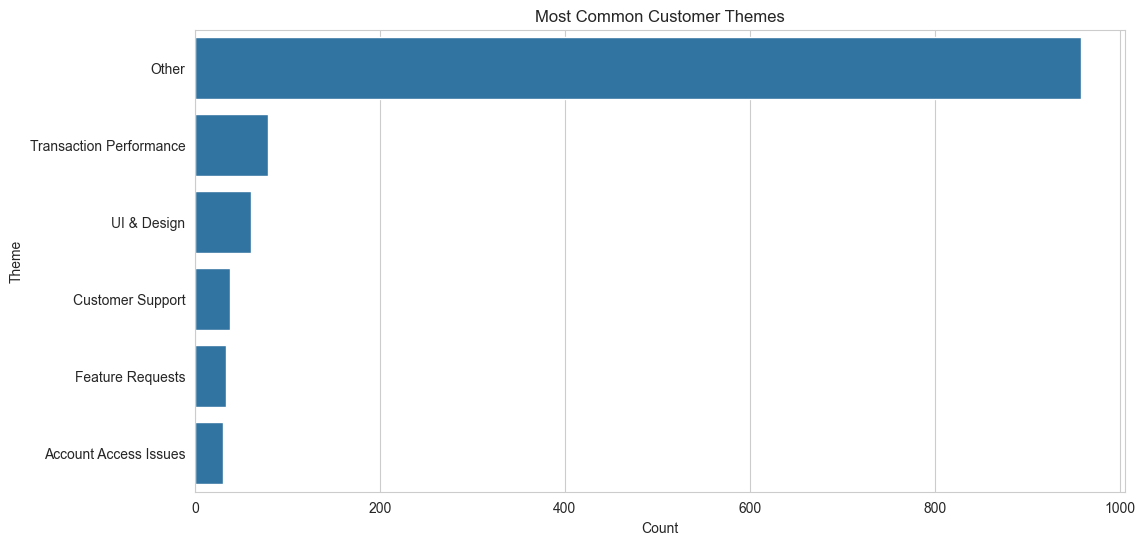

In [13]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=themes_df,
    y="identified_theme",
    order=themes_df[
        "identified_theme"
    ].value_counts().index
)

plt.title("Most Common Customer Themes")

plt.xlabel("Count")

plt.ylabel("Theme")

plt.show()

# Key Findings

## Major Observations

### 1. Positive Sentiment Dominates

Most customer reviews were classified as positive, indicating general satisfaction with the banking applications.

### 2. Transaction Performance Is a Common Concern

Several reviews highlighted:

- slow transfers
- delayed transactions
- payment processing issues

### 3. Account Access Problems

Users frequently mentioned:

- login issues
- OTP failures
- password-related problems

### 4. UI & Design Feedback

Many customers positively mentioned:

- ease of use
- clean interface
- accessibility

---

# Business Implications

The analysis suggests that:

- improving transaction reliability could significantly improve customer experience
- authentication systems require optimization
- customers value usability and interface simplicity

# Challenges Encountered

The following challenges were encountered during the analysis:

- multilingual customer reviews
- emoji-heavy text
- short ambiguous reviews
- transformer model limitations on very short text

---

# Next Steps

Future work will include:

- PostgreSQL integration
- dashboard visualization
- advanced topic modeling
- recommendation systems
- business intelligence reporting